# Personality Profiling with Clustering

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import DBSCAN
from mpl_toolkits.mplot3d import Axes3D

## 1. Data Preprocessing and Exploratory Data Analysis (EDA)

In [3]:
df = pd.read_csv("/content/drive/MyDrive/data-final.csv" , delimiter="\t")


In [4]:
df.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [5]:
df.shape

(1015341, 110)

In [6]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015341 entries, 0 to 1015340
Columns: 110 entries, EXT1 to long_appx_lots_of_err
dtypes: float64(104), int64(2), object(4)
memory usage: 852.1+ MB


In [7]:
print(df.columns.tolist())

['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9', 'EXT10', 'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10', 'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR5', 'AGR6', 'AGR7', 'AGR8', 'AGR9', 'AGR10', 'CSN1', 'CSN2', 'CSN3', 'CSN4', 'CSN5', 'CSN6', 'CSN7', 'CSN8', 'CSN9', 'CSN10', 'OPN1', 'OPN2', 'OPN3', 'OPN4', 'OPN5', 'OPN6', 'OPN7', 'OPN8', 'OPN9', 'OPN10', 'EXT1_E', 'EXT2_E', 'EXT3_E', 'EXT4_E', 'EXT5_E', 'EXT6_E', 'EXT7_E', 'EXT8_E', 'EXT9_E', 'EXT10_E', 'EST1_E', 'EST2_E', 'EST3_E', 'EST4_E', 'EST5_E', 'EST6_E', 'EST7_E', 'EST8_E', 'EST9_E', 'EST10_E', 'AGR1_E', 'AGR2_E', 'AGR3_E', 'AGR4_E', 'AGR5_E', 'AGR6_E', 'AGR7_E', 'AGR8_E', 'AGR9_E', 'AGR10_E', 'CSN1_E', 'CSN2_E', 'CSN3_E', 'CSN4_E', 'CSN5_E', 'CSN6_E', 'CSN7_E', 'CSN8_E', 'CSN9_E', 'CSN10_E', 'OPN1_E', 'OPN2_E', 'OPN3_E', 'OPN4_E', 'OPN5_E', 'OPN6_E', 'OPN7_E', 'OPN8_E', 'OPN9_E', 'OPN10_E', 'dateload', 'screenw', 'screenh', 'introelapse', 'testelapse', 'endelapse', 'IPC', 'count

In [8]:

missing_cols = df.columns[df.isnull().any()].tolist()

for col in missing_cols:
    print(f"{col}: {df[col].isnull().sum()}")


EXT1: 1783
EXT2: 1783
EXT3: 1783
EXT4: 1783
EXT5: 1783
EXT6: 1783
EXT7: 1783
EXT8: 1783
EXT9: 1783
EXT10: 1783
EST1: 1783
EST2: 1783
EST3: 1783
EST4: 1783
EST5: 1783
EST6: 1783
EST7: 1783
EST8: 1783
EST9: 1783
EST10: 1783
AGR1: 1783
AGR2: 1783
AGR3: 1783
AGR4: 1783
AGR5: 1783
AGR6: 1783
AGR7: 1783
AGR8: 1783
AGR9: 1783
AGR10: 1783
CSN1: 1783
CSN2: 1783
CSN3: 1783
CSN4: 1783
CSN5: 1783
CSN6: 1783
CSN7: 1783
CSN8: 1783
CSN9: 1783
CSN10: 1783
OPN1: 1783
OPN2: 1783
OPN3: 1783
OPN4: 1783
OPN5: 1783
OPN6: 1783
OPN7: 1783
OPN8: 1783
OPN9: 1783
OPN10: 1783
EXT1_E: 1783
EXT2_E: 1783
EXT3_E: 1783
EXT4_E: 1783
EXT5_E: 1783
EXT6_E: 1783
EXT7_E: 1783
EXT8_E: 1783
EXT9_E: 1783
EXT10_E: 1783
EST1_E: 1783
EST2_E: 1783
EST3_E: 1783
EST4_E: 1783
EST5_E: 1783
EST6_E: 1783
EST7_E: 1783
EST8_E: 1783
EST9_E: 1783
EST10_E: 1783
AGR1_E: 1783
AGR2_E: 1783
AGR3_E: 1783
AGR4_E: 1783
AGR5_E: 1783
AGR6_E: 1783
AGR7_E: 1783
AGR8_E: 1783
AGR9_E: 1783
AGR10_E: 1783
CSN1_E: 1783
CSN2_E: 1783
CSN3_E: 1783
CSN4_E: 1783


Since the number of missing vals are too few in comparison to the data so we remove them all/

In [4]:
df = df.dropna(axis=0)


In [5]:
df.shape

(1012050, 110)

In [9]:

missing_cols = df.columns[df.isnull().any()].tolist()
for col in missing_cols:
    print(f"{col}: {df[col].isnull().sum()}")


missing vals removed

Since scores are expected to be integers from 1 to 5, values outside this range or extreme values can be considered outliers.

In [6]:
personality_features = [
    'EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9', 'EXT10',
    'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10',
    'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR5', 'AGR6', 'AGR7', 'AGR8', 'AGR9', 'AGR10',
    'CSN1', 'CSN2', 'CSN3', 'CSN4', 'CSN5', 'CSN6', 'CSN7', 'CSN8', 'CSN9', 'CSN10',
    'OPN1', 'OPN2', 'OPN3', 'OPN4', 'OPN5', 'OPN6', 'OPN7', 'OPN8', 'OPN9', 'OPN10',

]
#  outliers (if the scores are not in the range of 1 to 5)
for col in personality_features:
    df[col] = df[col].clip(lower=1, upper=5)


In [11]:
df.shape

(1012050, 110)

In [7]:

X = df[personality_features]
print(X.describe())


               EXT1          EXT2          EXT3          EXT4          EXT5  \
count  1.012050e+06  1.012050e+06  1.012050e+06  1.012050e+06  1.012050e+06   
mean   2.651565e+00  2.779261e+00  3.294200e+00  3.147503e+00  3.286450e+00   
std    1.258217e+00  1.313594e+00  1.201226e+00  1.222848e+00  1.256462e+00   
min    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
25%    1.000000e+00  2.000000e+00  2.000000e+00  2.000000e+00  2.000000e+00   
50%    3.000000e+00  3.000000e+00  3.000000e+00  3.000000e+00  3.000000e+00   
75%    4.000000e+00  4.000000e+00  4.000000e+00  4.000000e+00  4.000000e+00   
max    5.000000e+00  5.000000e+00  5.000000e+00  5.000000e+00  5.000000e+00   

               EXT6          EXT7          EXT8          EXT9         EXT10  \
count  1.012050e+06  1.012050e+06  1.012050e+06  1.012050e+06  1.012050e+06   
mean   2.407226e+00  2.779599e+00  3.421088e+00  2.970516e+00  3.562753e+00   
std    1.216287e+00  1.387170e+00  1.257443e+00  1.

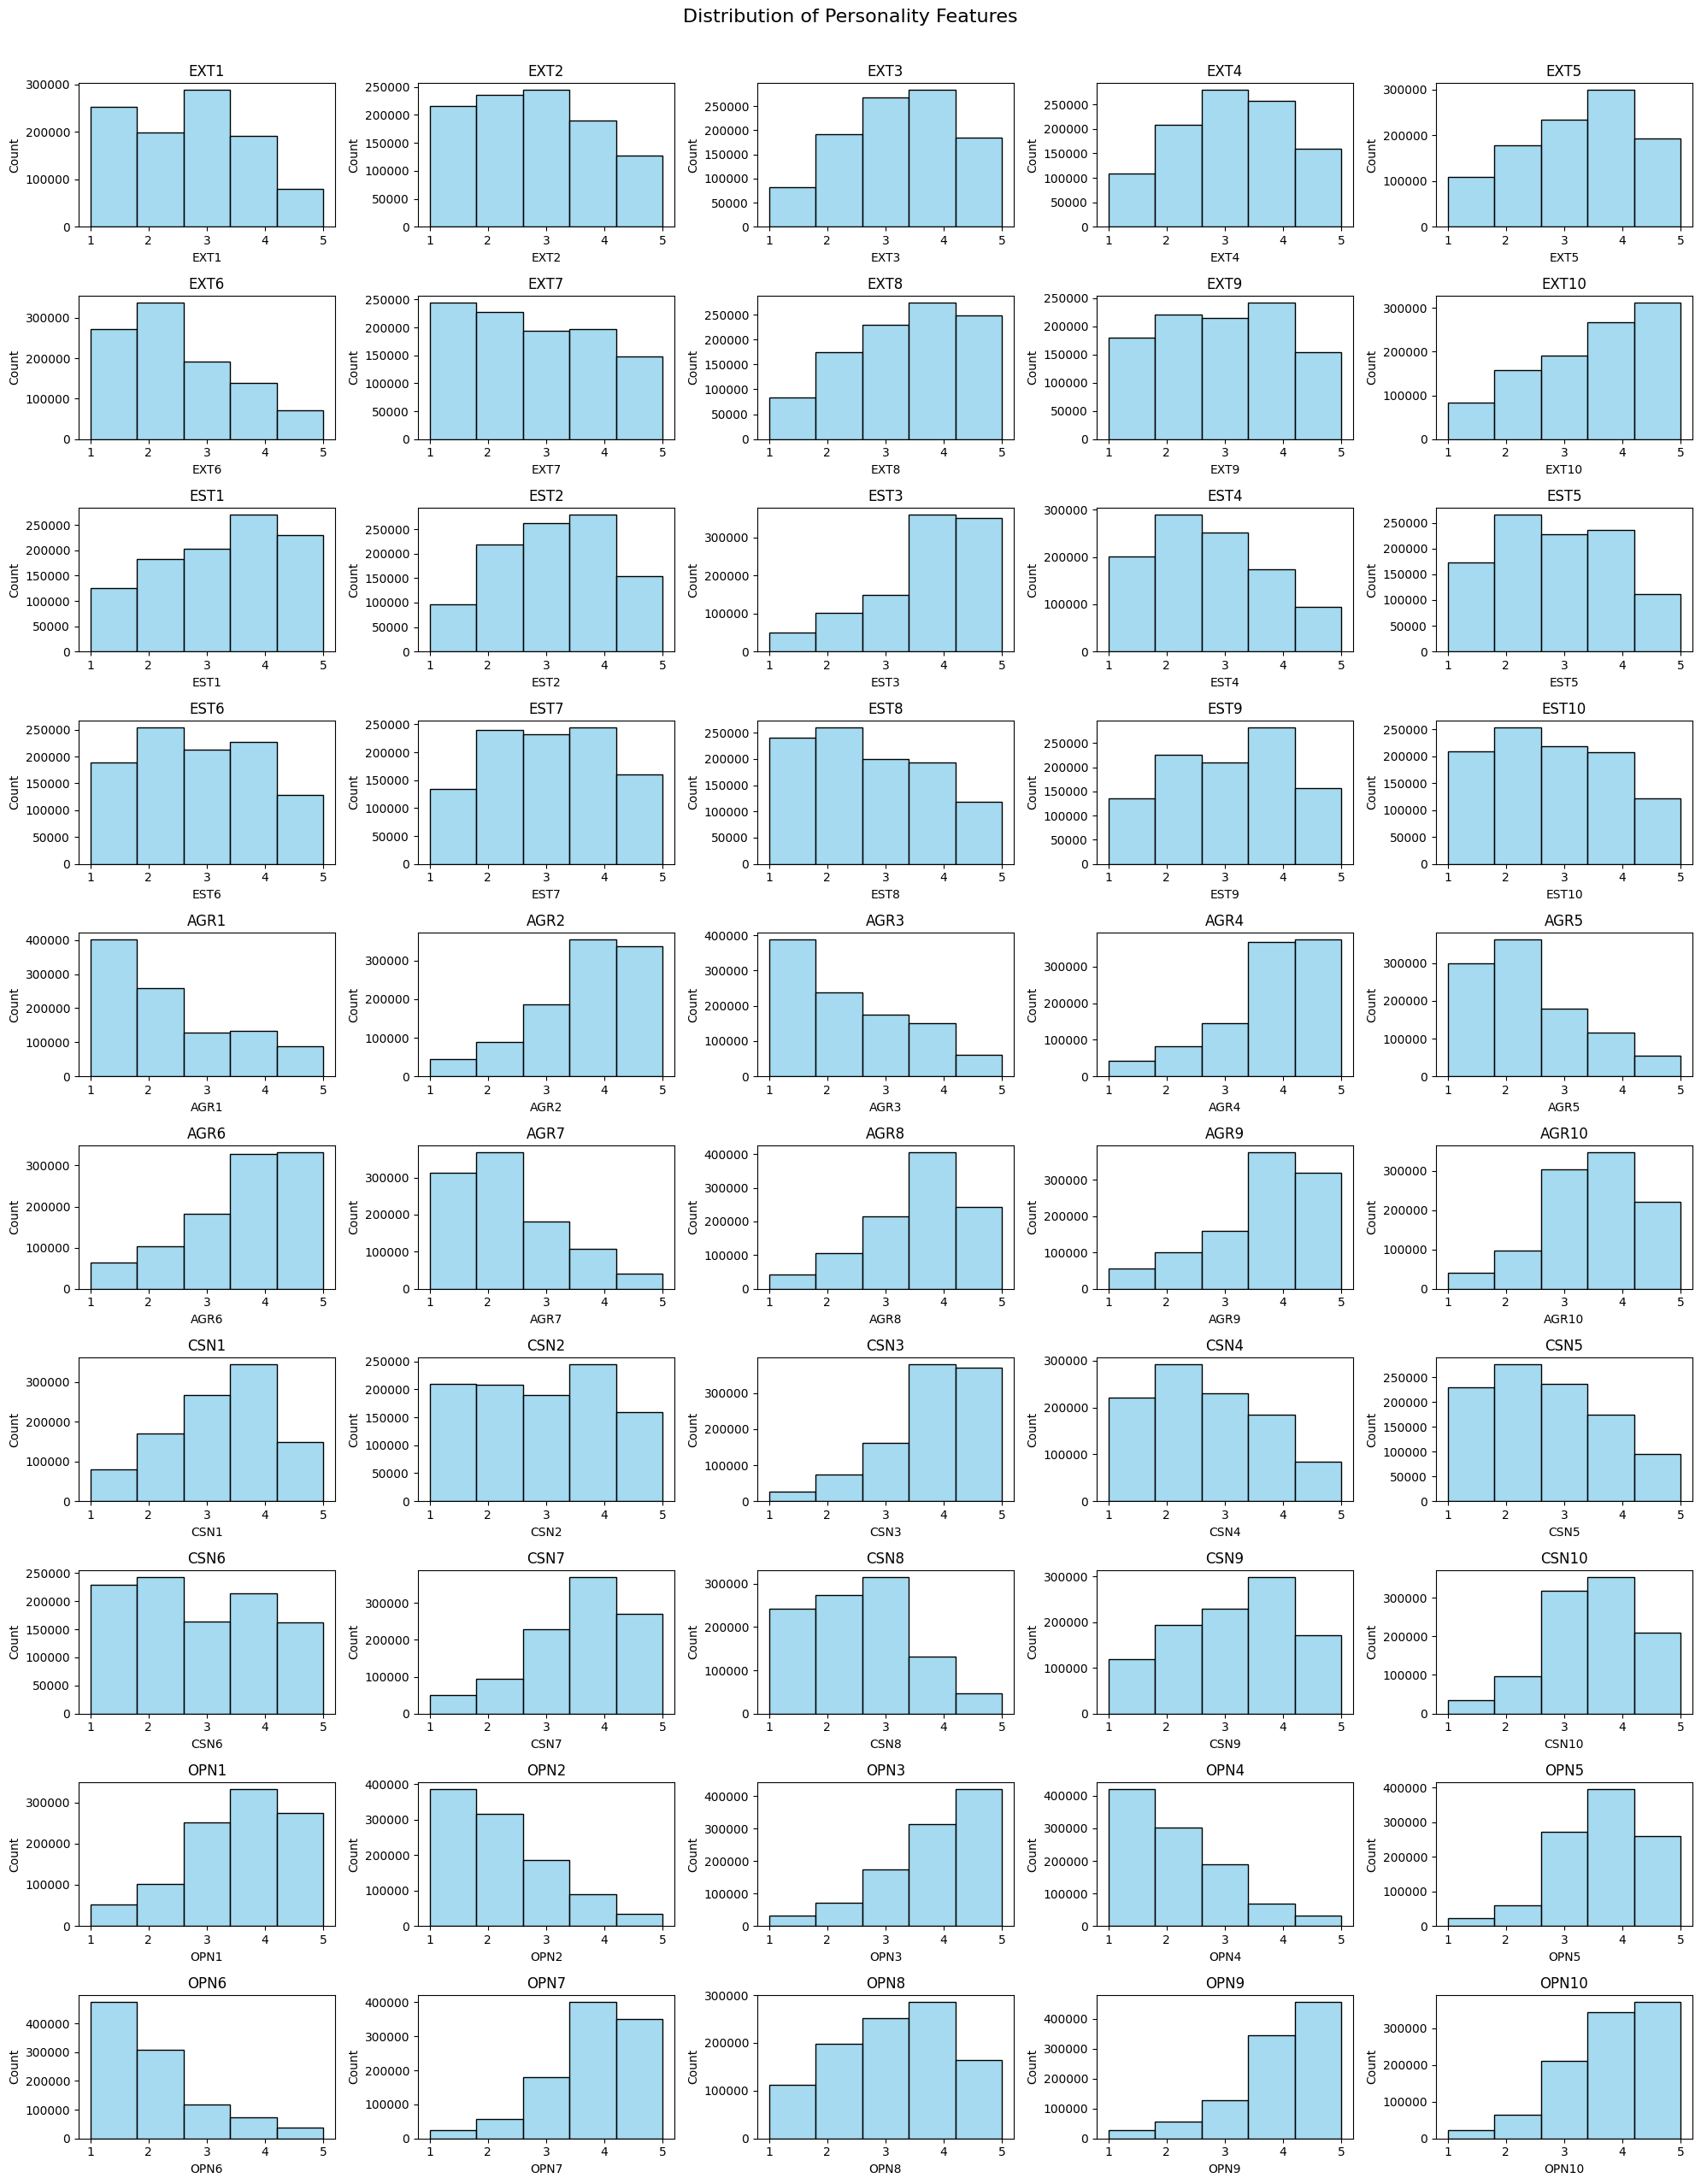

In [16]:
#Distribution per Feature
plt.figure(figsize=(20, 25))
for i, col in enumerate(personality_features):
    plt.subplot(10, 5, i+1)
    sns.histplot(X[col], bins=5, kde=False, color='skyblue')
    plt.title(col)
    plt.xticks([1, 2, 3, 4, 5])
    plt.tight_layout()
plt.suptitle("Distribution of Personality Features", y=1.02, fontsize=16)
plt.show()


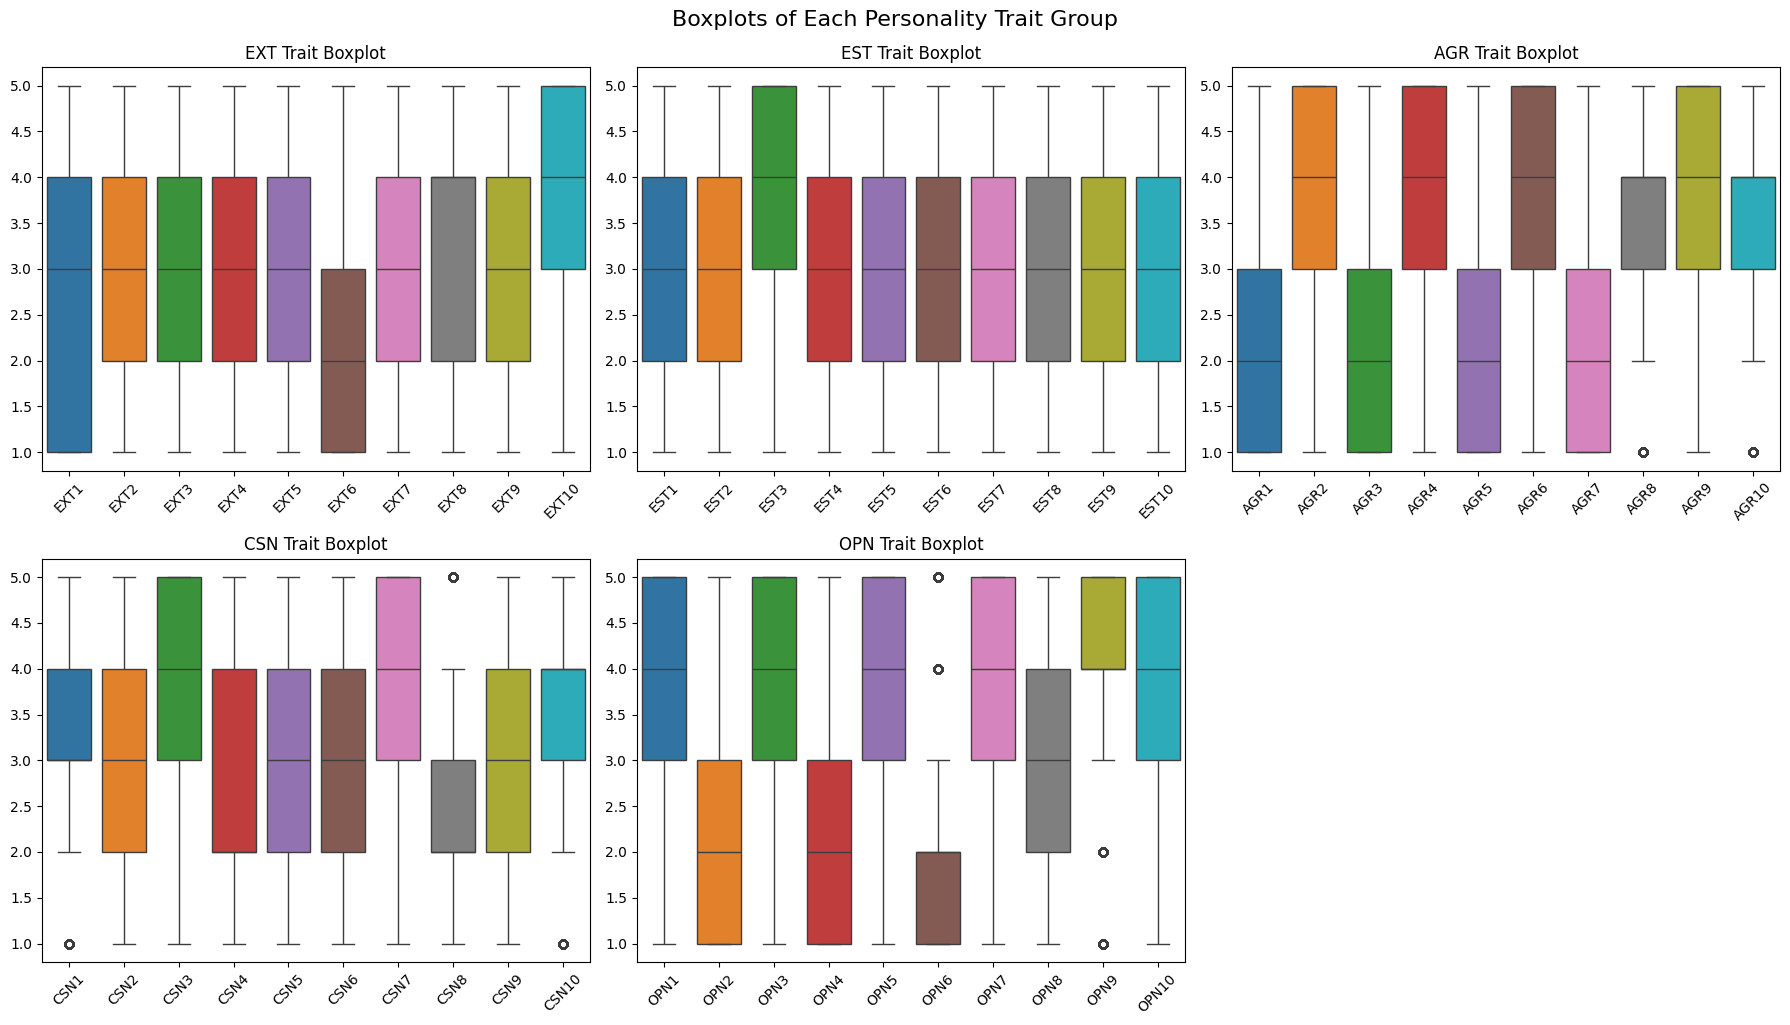

In [17]:
# Boxplot

trait_groups = {
    'EXT': [f'EXT{i}' for i in range(1, 11)],
    'EST': [f'EST{i}' for i in range(1, 11)],
    'AGR': [f'AGR{i}' for i in range(1, 11)],
    'CSN': [f'CSN{i}' for i in range(1, 11)],
    'OPN': [f'OPN{i}' for i in range(1, 11)]
}

plt.figure(figsize=(18, 10))
for i, (trait, cols) in enumerate(trait_groups.items()):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=X[cols])
    plt.title(f"{trait} Trait Boxplot")
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.suptitle("Boxplots of Each Personality Trait Group", y=1.02, fontsize=16)
plt.show()


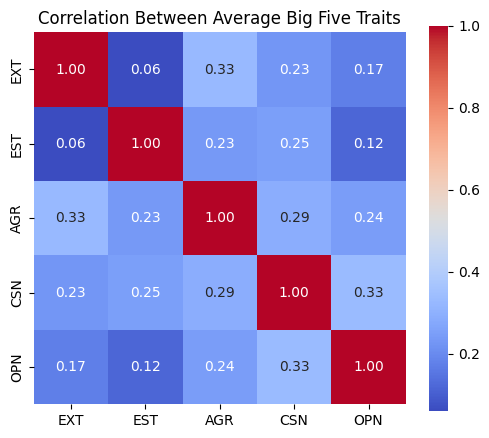

In [18]:
# Heatmap
trait_avg = pd.DataFrame({
    trait: X[cols].mean(axis=1) for trait, cols in trait_groups.items()
})

corr_matrix = trait_avg.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Between Average Big Five Traits")
plt.show()


In [8]:

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[personality_features])


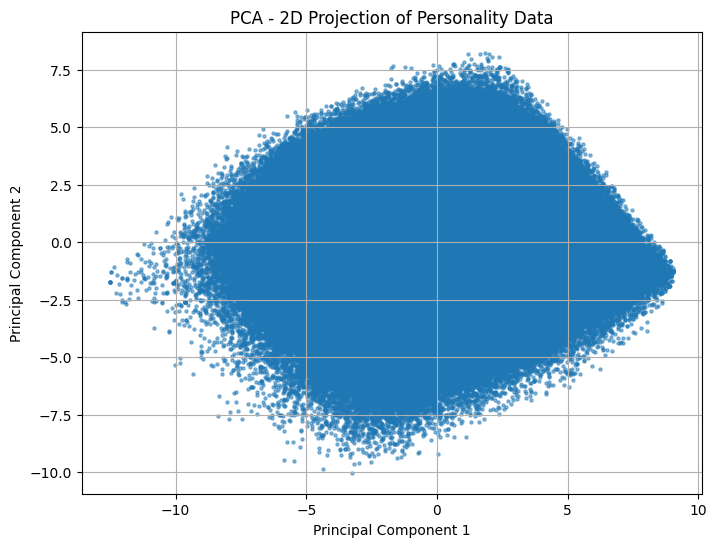

Explained variance by PCA components: [0.14745057 0.09865656]


In [9]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.5)
plt.title("PCA - 2D Projection of Personality Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

print("Explained variance by PCA components:", pca.explained_variance_ratio_)


 Why is Scaling Important?
Clustering algorithms (especially distance-based ones) rely on distance metrics (like Euclidean distance). If your features are not on the same scale:

Features with larger ranges will dominate the distance calculations, leading to biased clustering.

This can result in misleading clusters where the model gives undue importance to some variables.

In [8]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[personality_features])


## 2. Clustering Model Development and Evaluation

### K-maens

k=2 | Inertia=451913.01 | Silhouette=0.0893 | Davies-Bouldin=3.0001
k=3 | Inertia=430094.84 | Silhouette=0.0718 | Davies-Bouldin=3.0745
k=4 | Inertia=414948.02 | Silhouette=0.0618 | Davies-Bouldin=3.0784
k=5 | Inertia=404313.56 | Silhouette=0.0518 | Davies-Bouldin=2.9764
k=6 | Inertia=395671.58 | Silhouette=0.0509 | Davies-Bouldin=2.8666
k=7 | Inertia=388426.02 | Silhouette=0.0483 | Davies-Bouldin=2.9617
k=8 | Inertia=382255.13 | Silhouette=0.0475 | Davies-Bouldin=2.9897
k=9 | Inertia=376304.80 | Silhouette=0.0500 | Davies-Bouldin=2.7113
k=10 | Inertia=371775.98 | Silhouette=0.0445 | Davies-Bouldin=2.7939


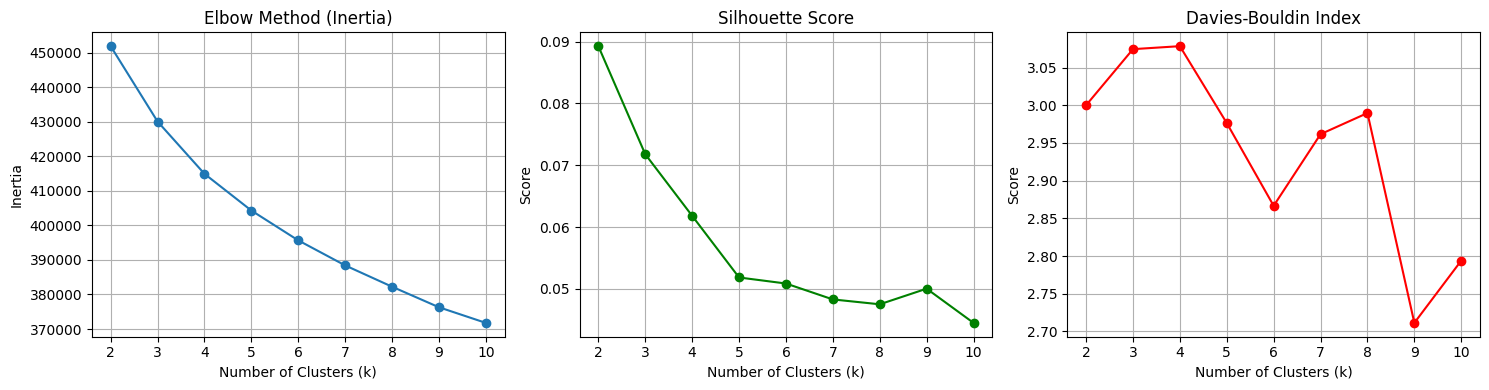

In [10]:

#sampling
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=10000, replace=False)
X_sample = X_scaled[sample_idx]

inertias = []
silhouette_scores = []
davies_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, algorithm='elkan', n_init='auto', random_state=42)
    labels = kmeans.fit_predict(X_sample)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_sample, labels)
    davies = davies_bouldin_score(X_sample, labels)

    inertias.append(inertia)
    silhouette_scores.append(silhouette)
    davies_scores.append(davies)

    print(f"k={k} | Inertia={inertia:.2f} | Silhouette={silhouette:.4f} | Davies-Bouldin={davies:.4f}")

plt.figure(figsize=(15, 4))

# Elbow
plt.subplot(1, 3, 1)
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)

# Silhouette
plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

# Davies-Bouldin
plt.subplot(1, 3, 3)
plt.plot(k_values, davies_scores, marker='o', color='red')
plt.title("Davies-Bouldin Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

### Hierarchical Clustering


 Linkage: WARD


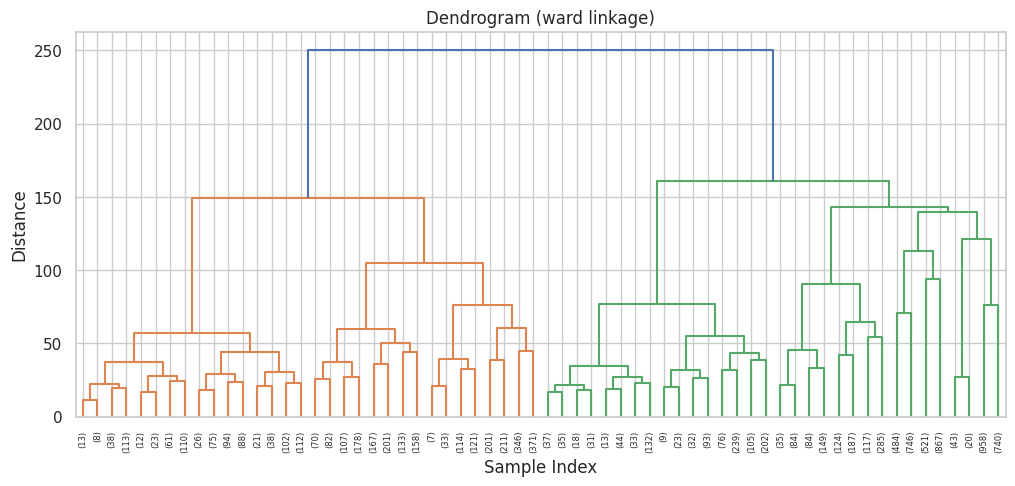


 Linkage: COMPLETE


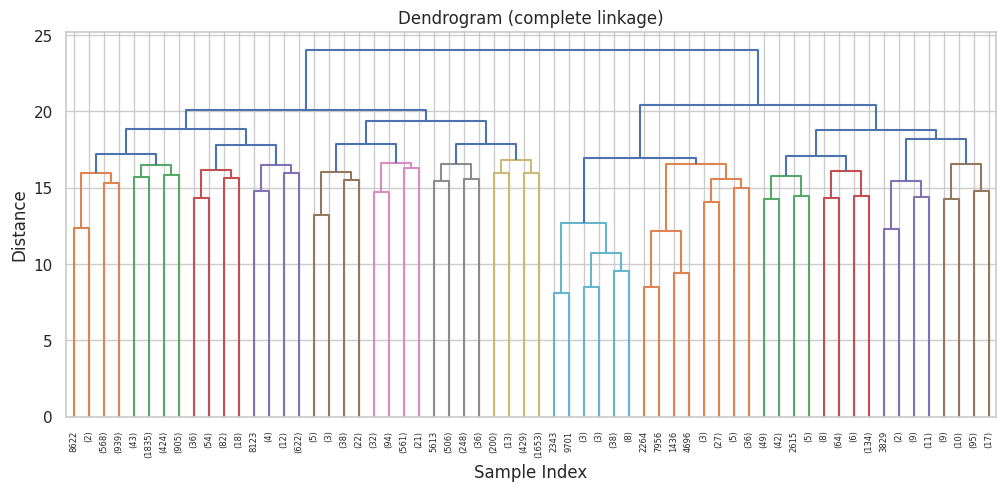


 Linkage: AVERAGE


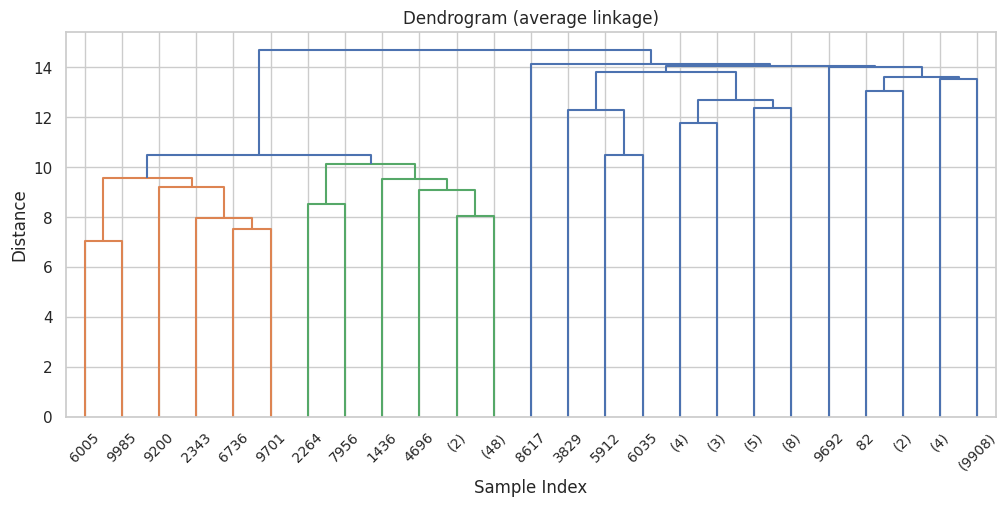


 Clustering Evaluation Results:


,Linkage,k,Silhouette Score,Davies-Bouldin Index
18,average,2,0.333964,0.920599
19,average,3,0.288328,0.799035
20,average,4,0.270561,1.356797
21,average,5,0.258610,1.239424
22,average,6,0.254958,1.275627
23,average,7,0.245320,1.376276
24,average,8,0.231055,1.416791
25,average,9,0.218792,1.328005
26,average,10,0.209709,1.262202
9,complete,2,0.139448,3.409029


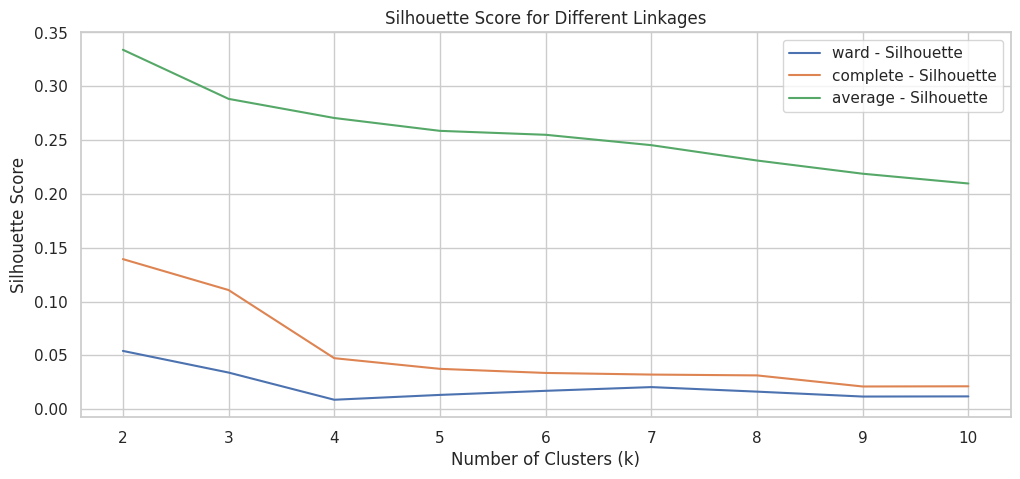

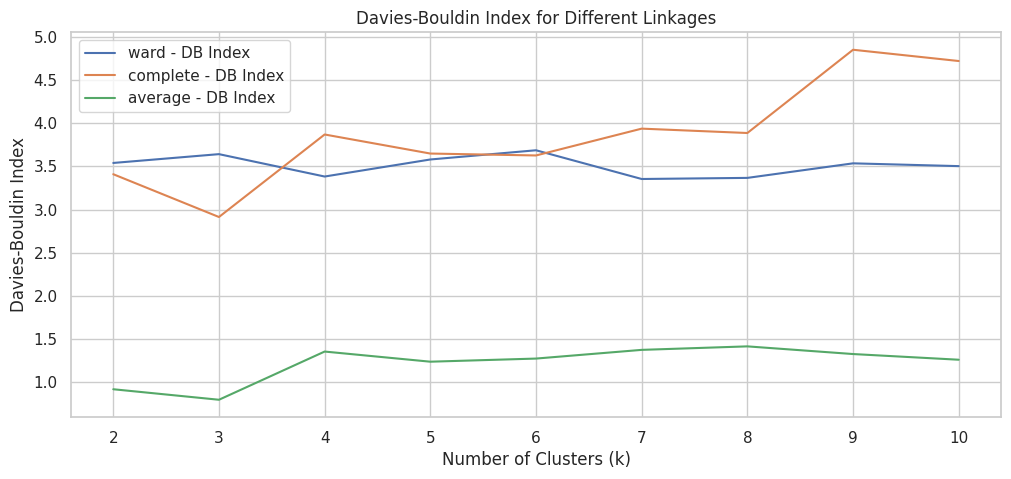

In [15]:

sns.set(style="whitegrid")

X_data = X_sample

linkage_methods = ['ward', 'complete', 'average']

cluster_range = range(2, 11)

results = []

for method in linkage_methods:
    print(f"\n Linkage: {method.upper()}")

    Z = linkage(X_data, method=method)

    plt.figure(figsize=(12, 5))
    plt.title(f'Dendrogram ({method} linkage)')
    dendrogram(Z, truncate_mode='level', p=5)
    plt.xlabel("Sample Index")
    plt.ylabel("Distance")
    plt.show()

    # eevalut for diffrent ks
    for k in cluster_range:

        labels = fcluster(Z, k, criterion='maxclust')

        # metris
        silhouette = silhouette_score(X_data, labels)
        db_index = davies_bouldin_score(X_data, labels)

        results.append({
            'Linkage': method,
            'k': k,
            'Silhouette Score': silhouette,
            'Davies-Bouldin Index': db_index
        })


results_df = pd.DataFrame(results)


print("\n Clustering Evaluation Results:")
display(results_df.sort_values(['Linkage', 'Silhouette Score'], ascending=[True, False]))


plt.figure(figsize=(12, 5))
for method in linkage_methods:
    subset = results_df[results_df['Linkage'] == method]
    plt.plot(subset['k'], subset['Silhouette Score'], label=f'{method} - Silhouette')
plt.title("Silhouette Score for Different Linkages")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for method in linkage_methods:
    subset = results_df[results_df['Linkage'] == method]
    plt.plot(subset['k'], subset['Davies-Bouldin Index'], label=f'{method} - DB Index')
plt.title("Davies-Bouldin Index for Different Linkages")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.legend()
plt.show()


### DBSCAN

In [17]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

pca = PCA(n_components=10, random_state=42)
X_reduced = pca.fit_transform(X_scaled)

# difine grid for eps and min samples
eps_values = np.arange(1.0, 3.1, 0.3)
min_samples_values = [2, 3, 4, 5]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_reduced)

        # Count clustres
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters >= 2:
            sil_score = silhouette_score(X_reduced, labels)
            db_index = davies_bouldin_score(X_reduced, labels)
        else:
            sil_score = -1
            db_index = np.inf

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'Silhouette Score': sil_score,
            'Davies-Bouldin Index': db_index
        })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette Score', ascending=False).reset_index(drop=True)

print("DBSCAN clustering results sorted by Silhouette Score:")
print(results_df)


best = results_df.iloc[0]
print("\nBest DBSCAN parameters found:")
print(f"eps = {best['eps']}")
print(f"min_samples = {best['min_samples']}")
print(f"Number of clusters: {best['n_clusters']}")
print(f"Number of noise points: {best['n_noise']}")
print(f"Silhouette Score: {best['Silhouette Score']:.4f}")
print(f"Davies-Bouldin Index: {best['Davies-Bouldin Index']:.4f}")


DBSCAN clustering results sorted by Silhouette Score:
    eps  min_samples  n_clusters  n_noise  Silhouette Score  \
0   3.1            5           3      497          0.155756   
1   2.8            5           3     1134          0.137856   
2   2.8            4           4     1041          0.126562   
3   3.1            4           3      457          0.113862   
4   3.1            3           5      428          0.044645   
5   2.5            5           5     2345         -0.049026   
6   2.8            3          12      934         -0.101655   
7   1.0            3           2     9962         -0.120995   
8   1.0            5           2     9962         -0.120995   
9   1.0            4           2     9962         -0.120995   
10  3.1            2          16      406         -0.123211   
11  1.3            5           2     9958         -0.129107   
12  2.5            4          11     2146         -0.173205   
13  2.5            3          26     1927         -0.247924   
1

## 3. Interpretation & Visualization

kmeans

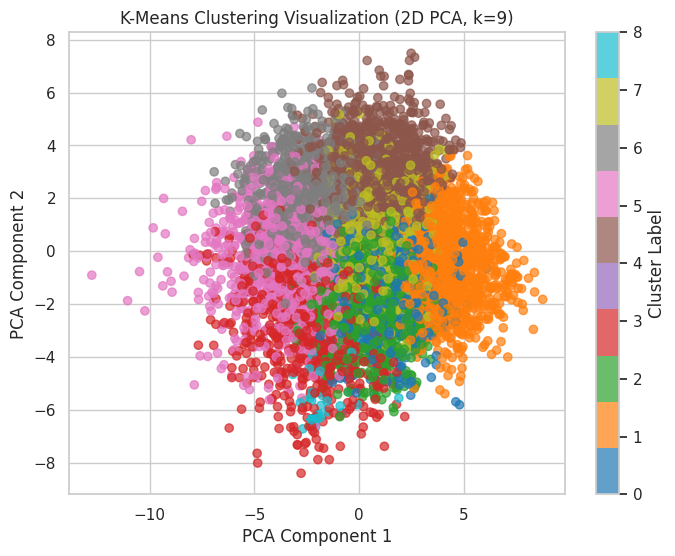

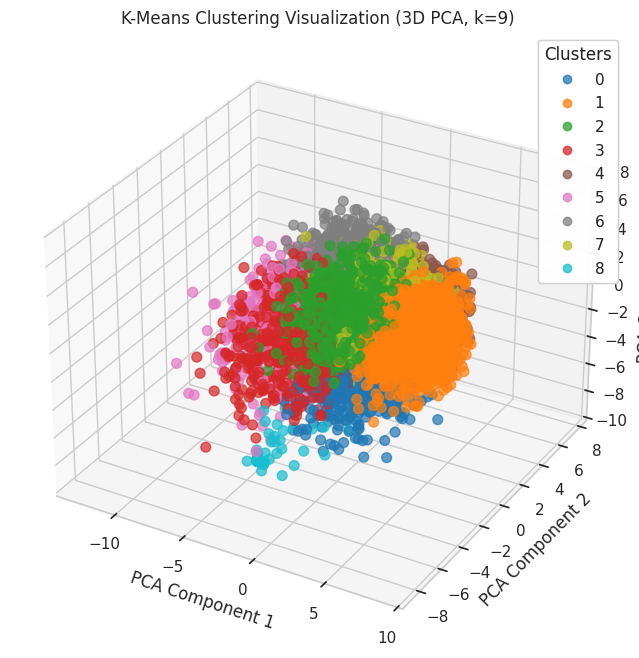

In [23]:

best_k = 9 #difined in the perevies sections
kmeans_best = KMeans(n_clusters=best_k, algorithm='elkan', n_init='auto', random_state=42)
cluster_labels = kmeans_best.fit_predict(X_sample)

# 2D
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)
plt.title(f"K-Means Clustering Visualization (2D PCA, k={best_k})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster Label')
plt.show()

# 3D
pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(X_sample)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter3d = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                       c=cluster_labels, cmap='tab10', alpha=0.7, s=50)
ax.set_title(f"K-Means Clustering Visualization (3D PCA, k={best_k})")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
legend1 = ax.legend(*scatter3d.legend_elements(), title="Clusters")
ax.add_artist(legend1)
plt.show()


In [27]:
feature_names = [f'Trait{i+1}' for i in range(X_sample.shape[1])]
X_df = pd.DataFrame(X_sample, columns=feature_names)
X_df['Cluster'] = cluster_labels
cluster_means = X_df.groupby('Cluster').mean(numeric_only=True)
print(cluster_means)


           Trait1    Trait2    Trait3    Trait4    Trait5    Trait6    Trait7  \
Cluster                                                                         
0        0.608283 -0.495513  0.526269 -0.595006  0.480000 -0.351991  0.536906   
1        0.696885 -0.721840  0.926904 -0.833152  0.896328 -0.711912  0.859566   
2       -0.517280  0.606399 -0.146662  0.564357 -0.430084  0.308579 -0.520754   
3       -0.651856  0.670981 -0.826684  0.584406 -0.806961  0.379252 -0.763062   
4        0.620615 -0.702776  0.380206 -0.578785  0.596972 -0.589451  0.608588   
5       -0.488982  0.542226 -0.601695  0.468115 -0.688555  0.833088 -0.574807   
6       -0.675090  0.555417 -0.839639  0.798496 -0.691789  0.358879 -0.741814   
7        0.346279 -0.289896  0.392785 -0.231131  0.384144 -0.048478  0.352608   
8       -0.569964 -0.930184 -1.473170 -1.568466 -1.480523 -1.076116 -1.176539   

           Trait8    Trait9   Trait10  ...   Trait41   Trait42   Trait43  \
Cluster                         

Hirechal

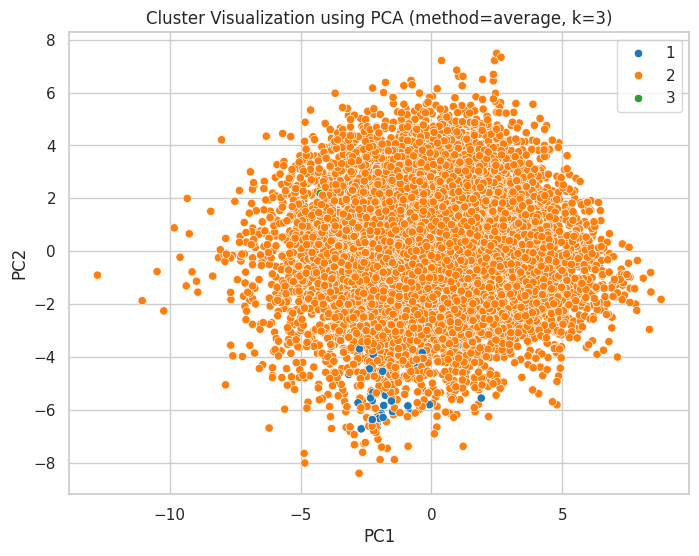

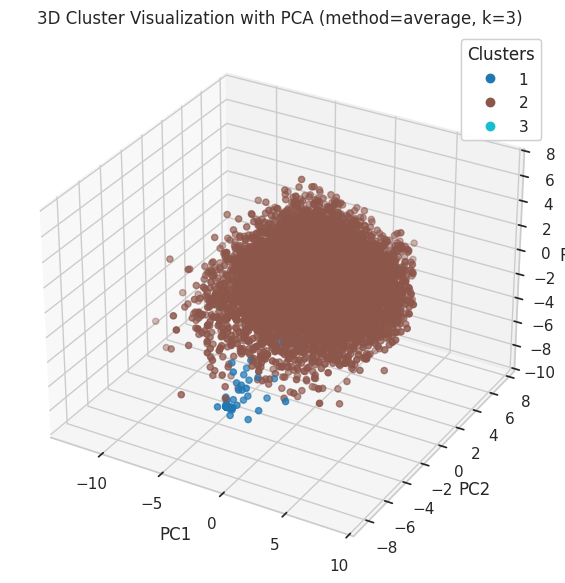

In [24]:
chosen_method = 'average'
chosen_k = 3
Z = linkage(X_data, method=chosen_method)

labels = fcluster(Z, chosen_k, criterion='maxclust')
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_data)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='tab10', legend='full')
plt.title(f'Cluster Visualization using PCA (method={chosen_method}, k={chosen_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# 3d


pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_data)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=labels, cmap='tab10')
ax.set_title(f'3D Cluster Visualization with PCA (method={chosen_method}, k={chosen_k})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
plt.show()




In [28]:
feature_names = [f'Trait{i+1}' for i in range(X_data.shape[1])]
X_df = pd.DataFrame(X_data, columns=feature_names)
X_df['Cluster'] = labels
cluster_means = X_df.groupby('Cluster').mean(numeric_only=True)
print(cluster_means)


           Trait1    Trait2    Trait3    Trait4    Trait5    Trait6    Trait7  \
Cluster                                                                         
1       -0.557587 -0.910424 -1.452017 -1.510820 -1.488134 -1.074768 -1.222825   
2        0.005526  0.003058  0.002592  0.010282 -0.006969  0.007328 -0.009896   
3        1.866480  1.690583 -1.909883  1.514905 -1.819753 -0.334811  1.600671   

           Trait8    Trait9   Trait10  ...   Trait41   Trait42   Trait43  \
Cluster                                ...                                 
1       -1.859135 -1.377598 -1.778985  ... -1.837839 -0.587053 -2.368085   
2        0.000625  0.012602 -0.001263  ...  0.002971  0.003215  0.005279   
3        1.255654 -1.477577  1.113565  ... -2.353117  2.642980 -2.803004   

          Trait44   Trait45   Trait46   Trait47   Trait48   Trait49   Trait50  
Cluster                                                                        
1       -0.668652 -2.517367 -0.687970 -2.979967 -1.67

dbscan

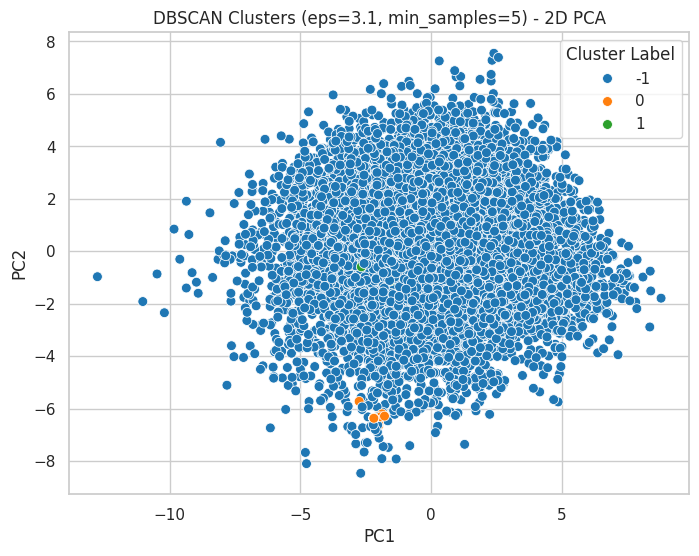

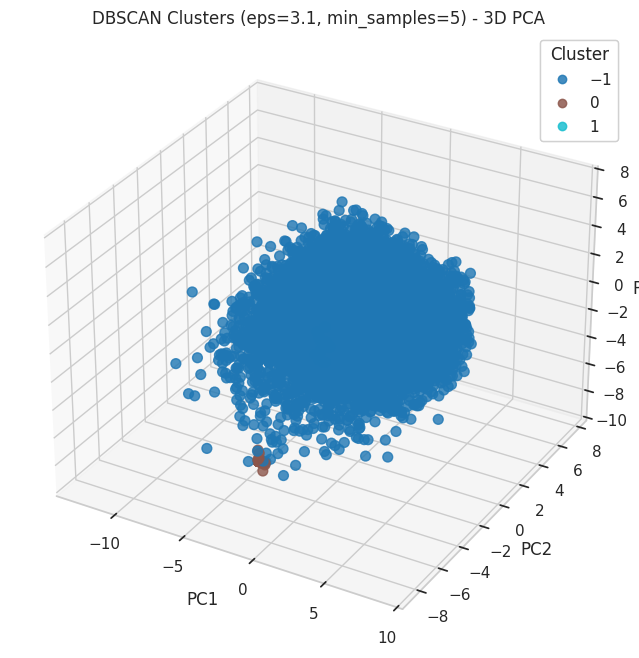

In [22]:
best_eps = 3.1
best_min_samples = 5
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = dbscan.fit_predict(X_scaled)

# 2D
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels, palette='tab10', legend='full', s=50)
plt.title(f'DBSCAN Clusters (eps={best_eps}, min_samples={best_min_samples}) - 2D PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster Label')
plt.show()

# 3D
from mpl_toolkits.mplot3d import Axes3D
pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], c=labels, cmap='tab10', s=50, alpha=0.8)
ax.set_title(f'DBSCAN Clusters (eps={best_eps}, min_samples={best_min_samples}) - 3D PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.show()


In [29]:
feature_names = [f'Trait{i+1}' for i in range(X_scaled.shape[1])]
X_df = pd.DataFrame(X_scaled, columns=feature_names)
X_df['Cluster'] = labels
X_clusters_only = X_df[X_df['Cluster'] != -1]
cluster_means = X_clusters_only.groupby('Cluster').mean(numeric_only=True)
print(cluster_means)


           Trait1    Trait2    Trait3    Trait4    Trait5    Trait6    Trait7  \
Cluster                                                                         
1       -0.556829 -0.910195 -1.445631 -1.511968 -1.472056 -1.071010 -1.204366   
2        0.003175  0.005324  0.008919  0.008975  0.009068  0.006499  0.007108   
3        1.853858  1.696612 -1.903478  1.513440 -1.803665 -0.334189  1.615742   

           Trait8    Trait9   Trait10  ...   Trait41   Trait42   Trait43  \
Cluster                                ...                                 
1       -1.850732 -1.390059 -1.761514  ... -1.818682 -0.584894 -2.347887   
2        0.011045  0.008542  0.010521  ...  0.011214  0.003266  0.014454   
3        1.267436 -1.490642  1.121783  ... -2.330905  2.633603 -2.780785   

          Trait44   Trait45   Trait46   Trait47   Trait48   Trait49   Trait50  
Cluster                                                                        
1       -0.671203 -2.509525 -0.688216 -2.945533 -1.66